# Patch spread: JPEG zig-zag metrics

Отдельный ноутбук для анализа того, как spatial-дельта от патча расползается по карте слоя. Нумерация клеток — JPEG zig-zag: старт из левого верхнего угла, обход по антидиагоналям с чередованием направления. Это не row-wise snake, а порядок вида `(0,0) → (0,1) → (1,0) → (2,0) → (1,1) → (0,2) ...`.


In [1]:
from pathlib import Path
import os
import sys

import pandas as pd

# Важно: старые кэши были созданы из cwd=new_experiments.
# Если VS Code запускает ноутбук из корня репозитория, переходим в new_experiments,
# иначе тот же output_dir начнёт указывать на пустую директорию и attack cache пересчитается.
cwd = Path.cwd()
if (cwd / "new_experiments" / "patch_success_analysis").exists():
    os.chdir(cwd / "new_experiments")
elif not (cwd / "patch_success_analysis").exists():
    raise RuntimeError(f"Unexpected cwd={cwd}; run from repo root or new_experiments")
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from patch_success_analysis import AttackConfig, ExperimentConfig, PatchSuccessExperiment

# Source cache: параметры большого уже сохранённого attack/sf кэша.
# Их не надо уменьшать ради быстрого анализа, иначе поменяется cache key и начнётся пересчёт.
source_pool_size = 7200
source_n_success = 3000
source_n_fail = 3000

# Analysis subset: сколько success/fail брать из большого кэша для zig-zag графиков.
# Это можно свободно менять: attack cache и sf при этом остаются большими и грузятся с диска.
analysis_examples_per_class = 100

attack_config = AttackConfig(
    dataset_path=["../datasets/celeb_fbi_640"],
    patch_path="../data/patch.png",
    model_path="yolo11s.pt",
    output_dir="new_experiments/outputs/patch_success_analysis",
    pool_size=source_pool_size,
    n_success=source_n_success,
    n_fail=source_n_fail,
    inference_batch_size=32,
    show_progress=True,
    success_thresh=0.30,
    seed=17,
    device="mps",
    conf=0.01,
)

config = ExperimentConfig(
    attack=attack_config,
    target_layer="model.22",
    n_steps=8,
    alpha_batch_size=8,
    metrics_batch_size=1024,
)
exp = PatchSuccessExperiment(config)
print(f"cwd={Path.cwd()}")
print(f"source attack cache key={attack_config.cache_key()}")
print(f"source attack cache path={attack_config.cache_path}")
cache = exp.build_or_load_cache(force=False)

force_success_failure_metrics_recompute = False
sf = exp.run_segmentig_success_failure_metrics(force=force_success_failure_metrics_recompute)
rows_df_full = pd.DataFrame(sf["rows"])
success_rows = rows_df_full[rows_df_full["success"].astype(bool)].head(analysis_examples_per_class)
fail_rows = rows_df_full[~rows_df_full["success"].astype(bool)].head(analysis_examples_per_class)
if len(success_rows) < analysis_examples_per_class or len(fail_rows) < analysis_examples_per_class:
    raise RuntimeError(
        f"Need {analysis_examples_per_class} success/fail rows in source sf, "
        f"got {len(success_rows)} / {len(fail_rows)}"
    )
rows_df = pd.concat([success_rows, fail_rows], ignore_index=True)
print(f"source examples={len(rows_df_full)}, sf_loaded_from_cache={sf.get('loaded_from_cache')}")
print(f"analysis examples={len(rows_df)} ({len(success_rows)} success / {len(fail_rows)} fail)")
print(sf.get("cache_path"))


cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
source attack cache key=34df6a12b82dd284
source attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_34df6a12b82dd284.pkl
source examples=6000, sf_loaded_from_cache=True
analysis examples=200 (100 success / 100 fail)
new_experiments/outputs/patch_success_analysis/cache/segmentig_success_failure_metrics_b1163b3ceaf28fbd.pkl


In [2]:
import hashlib
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from patch_success_analysis.activations import compute_layer_deltas
from patch_success_analysis.metrics import (
    delta_zigzag_profile,
    jpeg_zigzag_indices,
    metric_quality_rows,
    normalized_cumulative_auc,
    normalized_cumulative_curve,
)
from patch_success_analysis.plots import plot_metric_distribution_and_roc

zigzag_layer_name = "model.22"
zigzag_examples_per_class = analysis_examples_per_class
zigzag_modes = ["mean_abs", "signed_mean"]
zigzag_rng = np.random.default_rng(31)

def _resolve_existing_path(path_like):
    path = Path(path_like)
    candidates = [path, Path.cwd() / path]
    text = str(path)
    if text.startswith("new_experiments/outputs/"):
        candidates.append(Path("new_experiments") / path)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(path_like)

def _stack_profiles(values):
    min_len = min(len(v) for v in values)
    return np.stack([np.asarray(v[:min_len], dtype="float64") for v in values], axis=0)

def _profile_group_stats(records, mode):
    rows = []
    for success_value, label in [(True, "success"), (False, "fail")]:
        profiles = [item[f"profile_{mode}"] for item in records if bool(item["success"]) == success_value]
        stack = _stack_profiles(profiles)
        rows.append({
            "label": label,
            "success": success_value,
            "x": np.linspace(0.0, 1.0, stack.shape[1]),
            "mean": stack.mean(axis=0),
            "std": stack.std(axis=0),
        })
    return rows

def _cumulative_group_stats(records, mode):
    rows = []
    for success_value, label in [(True, "success"), (False, "fail")]:
        curves = []
        for item in records:
            if bool(item["success"]) != success_value:
                continue
            x, y = normalized_cumulative_curve(item[f"profile_{mode}"])
            curves.append(y)
        stack = _stack_profiles(curves)
        rows.append({
            "label": label,
            "success": success_value,
            "x": np.linspace(0.0, 1.0, stack.shape[1]),
            "mean": stack.mean(axis=0),
            "std": stack.std(axis=0),
        })
    return rows

def _plot_group_lines(stats, title, ylabel, *, with_std=False):
    fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
    colors = {"success": "#4C78A8", "fail": "#F58518"}
    for row in stats:
        color = colors[row["label"]]
        ax.plot(row["x"], row["mean"], label=row["label"], color=color)
        if with_std:
            ax.fill_between(row["x"], row["mean"] - row["std"], row["mean"] + row["std"], color=color, alpha=0.18)
    ax.set_title(title)
    ax.set_xlabel("normalized JPEG zig-zag cell index")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()


### Patch spread по всем слоям на одной картинке

Берём один success-example и считаем clean/patched delta на всех display-слоях. Каналы схлопываем через `mean_abs`, затем разворачиваем spatial-карту в JPEG zig-zag profile. Это нужно как sanity check: видно, где по порядку карты концентрируется изменение от патча на разных слоях.


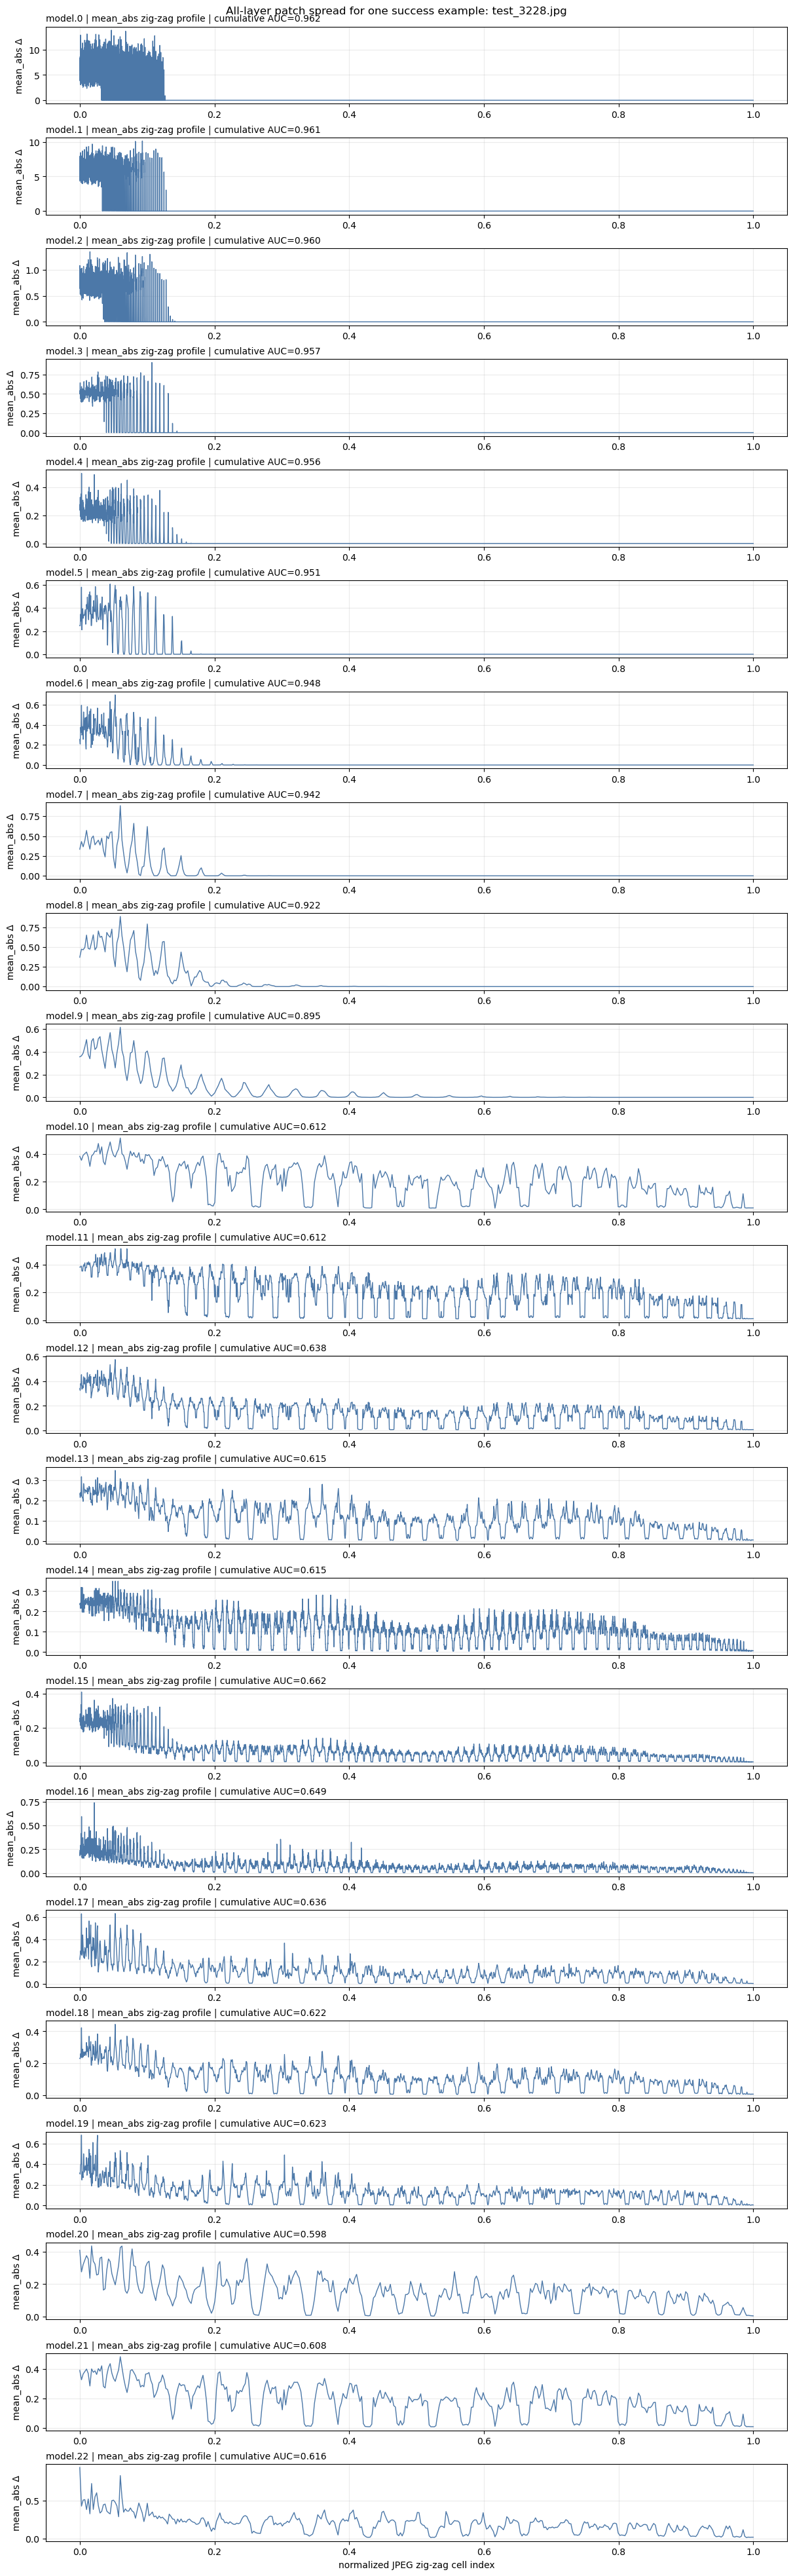

,layer,auc
0,model.0,0.962415
1,model.1,0.961358
2,model.2,0.959753
3,model.3,0.957102
4,model.4,0.955908
5,model.5,0.951124
6,model.6,0.947609
7,model.7,0.941523
8,model.8,0.922443
9,model.9,0.895201


In [3]:
cache = exp.get_cache()
one_example = cache.successes[0] if cache.successes else cache.examples[0]
layer_names = exp.all_display_layer_names()
_yolo, model = exp.load_model()
ctx = exp._context_for_example(one_example, image_variant="clean")
clean_pack = exp._preprocess(ctx["clean_lb"])
patched_pack = exp._preprocess(ctx["patched_lb"])
deltas = compute_layer_deltas(model, clean_pack["im"], patched_pack["im"], layer_names)

all_layer_profiles = []
for layer_name in layer_names:
    if layer_name not in deltas:
        continue
    profile = delta_zigzag_profile(deltas[layer_name].delta, mode="mean_abs")
    all_layer_profiles.append({
        "layer": layer_name,
        "x": np.linspace(0.0, 1.0, len(profile)),
        "profile": profile,
        "auc": normalized_cumulative_auc(profile),
    })

fig, axes = plt.subplots(len(all_layer_profiles), 1, figsize=(12, max(8, 1.7 * len(all_layer_profiles))), sharex=False, constrained_layout=True)
if len(all_layer_profiles) == 1:
    axes = [axes]
for ax, row in zip(axes, all_layer_profiles):
    ax.plot(row["x"], row["profile"], color="#4C78A8", linewidth=1.0)
    ax.set_title(f"{row['layer']} | mean_abs zig-zag profile | cumulative AUC={row['auc']:.3f}", loc="left", fontsize=10)
    ax.set_ylabel("mean_abs Δ")
    ax.grid(alpha=0.25)
axes[-1].set_xlabel("normalized JPEG zig-zag cell index")
fig.suptitle(f"All-layer patch spread for one success example: {Path(one_example.path).name}", y=1.002)
plt.show()

display(pd.DataFrame([{k: v for k, v in row.items() if k not in {"x", "profile"}} for row in all_layer_profiles]))


### Patch spread на 22 слое: success vs fail

Теперь берём 100 success и 100 fail, но уже не считаем IG и не гоняем модель. Используем `delta_chw` из `layer_maps_cache_path`, строим два набора профилей: `mean_abs` и `signed_mean`. На первом графике показываем только средние, на втором — средние с `± std`.


saved zigzag cache: new_experiments/outputs/patch_success_analysis/cache/patch_spread_zigzag_85e64c9d03c0b456.pkl
zigzag examples=200 | success=100 | fail=100


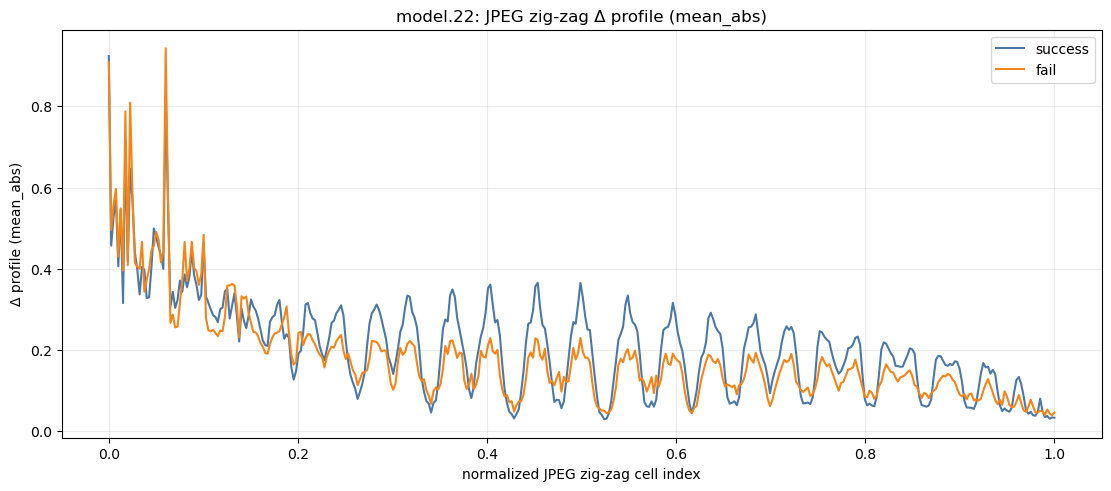

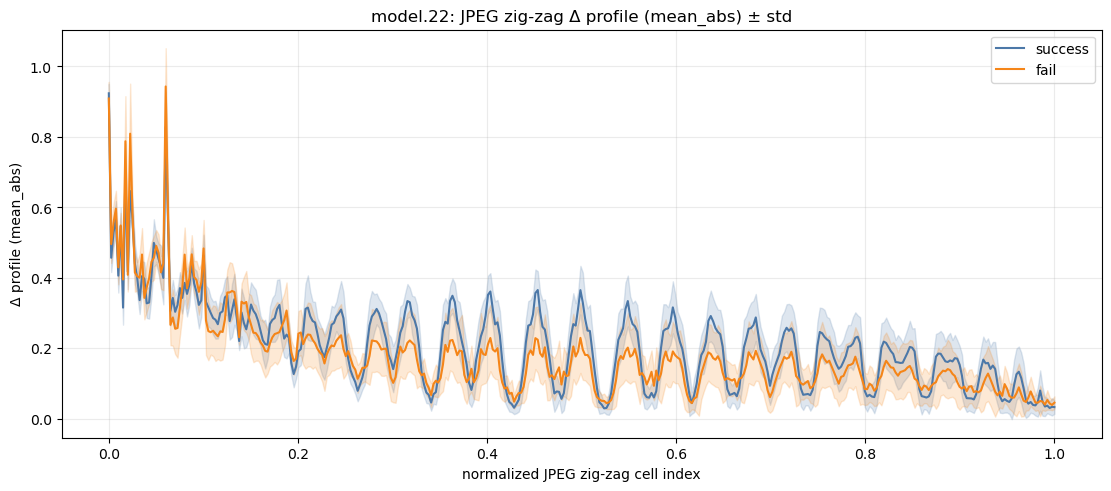

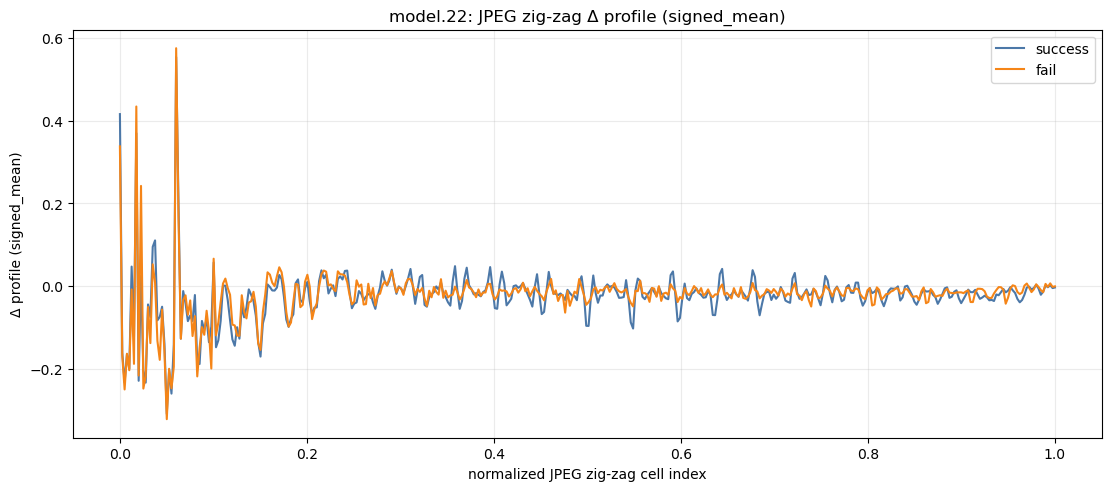

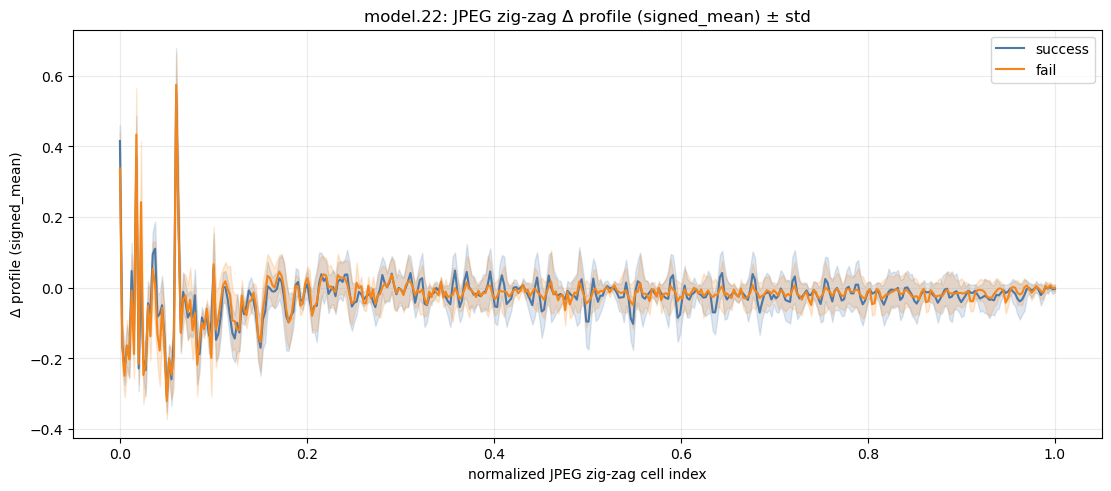

In [ ]:
rows_df = pd.DataFrame(sf["rows"])
success_rows = rows_df[rows_df["success"].astype(bool)].head(zigzag_examples_per_class)
fail_rows = rows_df[~rows_df["success"].astype(bool)].head(zigzag_examples_per_class)
if len(success_rows) < zigzag_examples_per_class or len(fail_rows) < zigzag_examples_per_class:
    raise RuntimeError(f"Need {zigzag_examples_per_class} success and fail rows, got {len(success_rows)} / {len(fail_rows)}")
selected_zigzag_rows = pd.concat([success_rows, fail_rows], ignore_index=True)

cache_payload = {
    "version": 1,
    "sf_cache_path": sf.get("cache_path"),
    "layer": zigzag_layer_name,
    "examples_per_class": zigzag_examples_per_class,
    "paths": selected_zigzag_rows["path"].tolist(),
    "modes": zigzag_modes,
}
cache_key = hashlib.sha256(json.dumps(cache_payload, sort_keys=True, ensure_ascii=True).encode("utf-8")).hexdigest()[:16]
zigzag_cache_path = exp.derived_cache_dir / f"patch_spread_zigzag_{cache_key}.pkl"

if zigzag_cache_path.exists():
    with zigzag_cache_path.open("rb") as f:
        zigzag_records = pickle.load(f)
    print(f"loaded zigzag cache: {zigzag_cache_path}")
else:
    zigzag_records = []
    for _, row in selected_zigzag_rows.iterrows():
        layer_map_path = _resolve_existing_path(row["layer_maps_cache_path"])
        with np.load(layer_map_path, allow_pickle=False) as data:
            delta_chw = data["delta_chw"].astype("float32", copy=False)
        item = {
            "path": row["path"],
            "success": bool(row["success"]),
            "drop": float(row["drop"]),
            "layer_maps_cache_path": str(layer_map_path),
        }
        for mode in zigzag_modes:
            profile = delta_zigzag_profile(delta_chw, mode=mode)
            item[f"profile_{mode}"] = profile
            item[f"zigzag_cumulative_auc_{mode}"] = normalized_cumulative_auc(profile)
        zigzag_records.append(item)
    with zigzag_cache_path.open("wb") as f:
        pickle.dump(zigzag_records, f)
    print(f"saved zigzag cache: {zigzag_cache_path}")

print(f"zigzag examples={len(zigzag_records)} | success={sum(r['success'] for r in zigzag_records)} | fail={sum(not r['success'] for r in zigzag_records)}")
for mode in zigzag_modes:
    stats = _profile_group_stats(zigzag_records, mode)
    _plot_group_lines(stats, f"{zigzag_layer_name}: JPEG zig-zag Δ profile ({mode})", f"Δ profile ({mode})", with_std=False)
    _plot_group_lines(stats, f"{zigzag_layer_name}: JPEG zig-zag Δ profile ({mode}) ± std", f"Δ profile ({mode})", with_std=True)

# +5 +4 +0 -1 -2

### Кумулятивное расползание и AUC

Кумулятивная версия показывает, насколько быстро mass дельты набирается вдоль JPEG zig-zag порядка. Для `signed_mean` тоже берём `abs(profile)`, потому что тут нас интересует расползание magnitude, а не знак. AUC нормирован: `x` в `[0,1]`, cumulative mass заканчивается в `1`.


zigzag_cumulative_auc_mean_abs                  \
                                  mean       std count   
success                                                  
False                         0.641286  0.032243   100   
True                          0.611126  0.023617   100   

        zigzag_cumulative_auc_signed_mean                  
                                     mean       std count  
success                                                    
False                            0.679307  0.039504   100  
True                             0.642421  0.033318   100

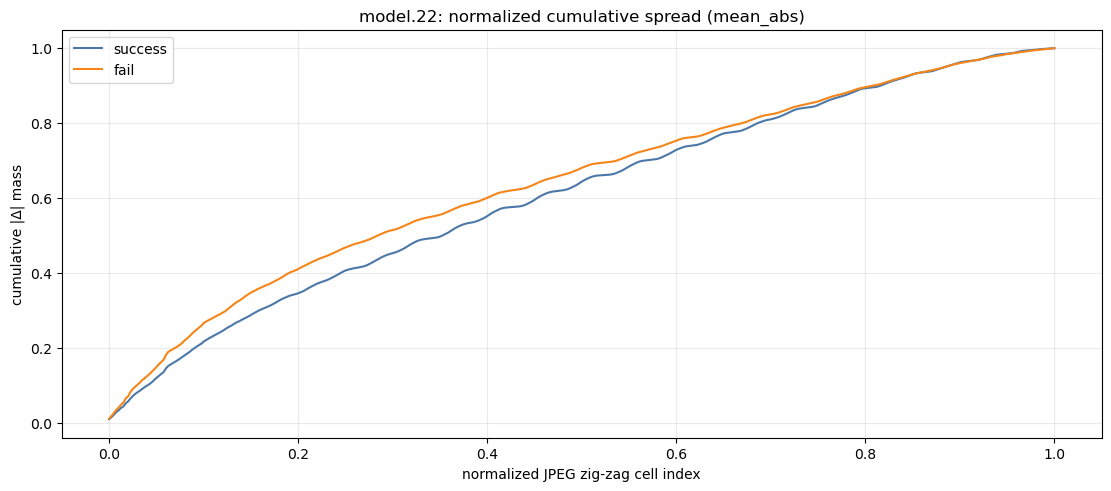

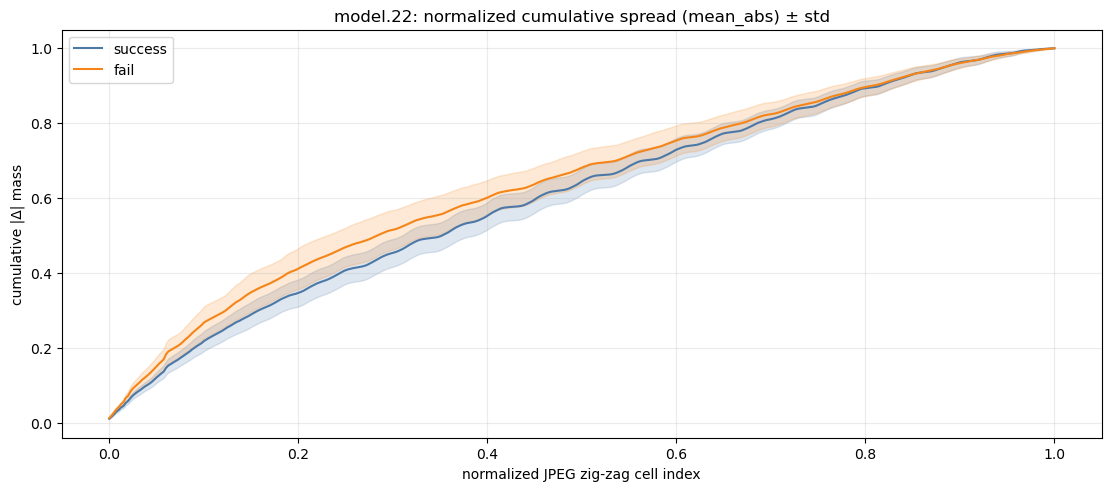

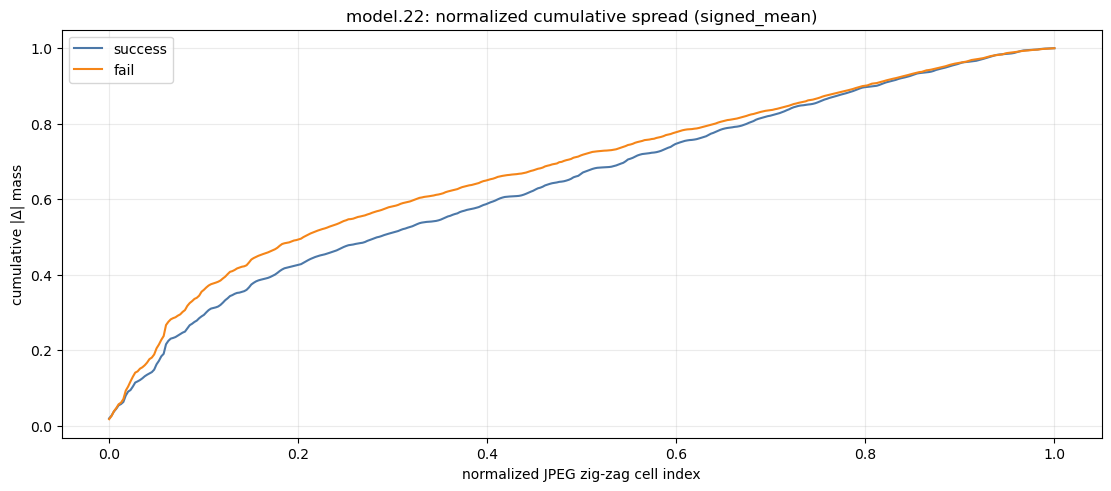

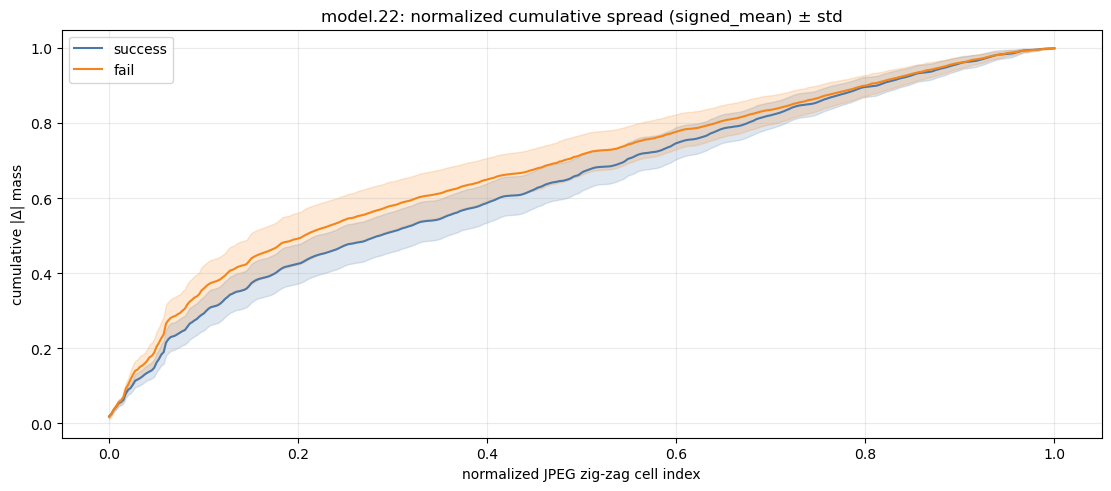

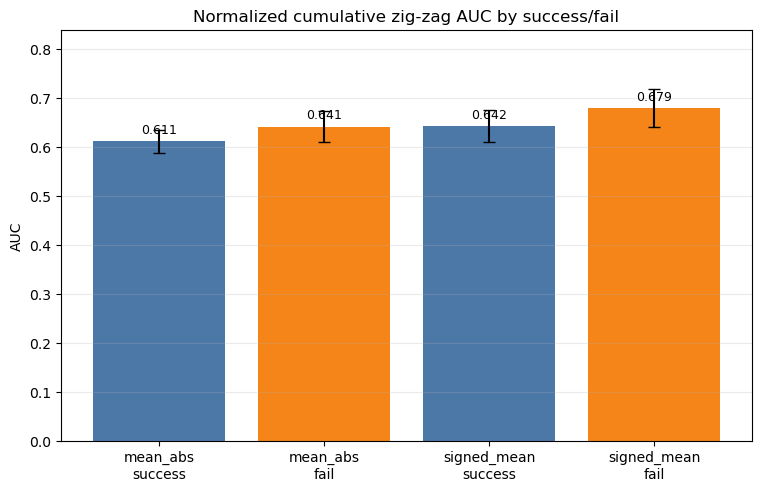

In [5]:
zigzag_metric_rows = []
for item in zigzag_records:
    out = {"path": item["path"], "success": bool(item["success"]), "drop": float(item["drop"])}
    for mode in zigzag_modes:
        out[f"zigzag_cumulative_auc_{mode}"] = float(item[f"zigzag_cumulative_auc_{mode}"])
    zigzag_metric_rows.append(out)
zigzag_metrics_df = pd.DataFrame(zigzag_metric_rows)
display(zigzag_metrics_df.groupby("success")[[f"zigzag_cumulative_auc_{mode}" for mode in zigzag_modes]].agg(["mean", "std", "count"]))

for mode in zigzag_modes:
    stats = _cumulative_group_stats(zigzag_records, mode)
    _plot_group_lines(stats, f"{zigzag_layer_name}: normalized cumulative spread ({mode})", "cumulative |Δ| mass", with_std=False)
    _plot_group_lines(stats, f"{zigzag_layer_name}: normalized cumulative spread ({mode}) ± std", "cumulative |Δ| mass", with_std=True)

bar_rows = []
for mode in zigzag_modes:
    metric = f"zigzag_cumulative_auc_{mode}"
    for success_value, label in [(True, "success"), (False, "fail")]:
        values = zigzag_metrics_df.loc[zigzag_metrics_df["success"] == success_value, metric].astype("float64")
        bar_rows.append({"mode": mode, "label": label, "mean": values.mean(), "std": values.std()})
bar_df = pd.DataFrame(bar_rows)
fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
labels = [f"{row.mode}\n{row.label}" for row in bar_df.itertuples()]
x = np.arange(len(bar_df))
colors = ["#4C78A8" if label.endswith("success") else "#F58518" for label in labels]
bars = ax.bar(x, bar_df["mean"], yerr=bar_df["std"], capsize=4, color=colors)
for bar, value in zip(bars, bar_df["mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.0, min(1.0, float((bar_df["mean"] + bar_df["std"].fillna(0)).max()) + 0.12))
ax.set_title("Normalized cumulative zig-zag AUC by success/fail")
ax.set_ylabel("AUC")
ax.grid(axis="y", alpha=0.25)
plt.show()


### Разделение success/fail по zig-zag AUC

Проверяем, насколько normalized cumulative AUC сам по себе разделяет success/fail: строим distribution + ROC и выводим те же `roc_auc`, `best_accuracy`, `best_threshold`, `best_direction`.


,metric,roc_auc,best_accuracy,best_threshold,best_direction
1,zigzag_cumulative_auc_signed_mean,0.2428,0.735,0.667736,-1
0,zigzag_cumulative_auc_mean_abs,0.2317,0.725,0.622462,-1


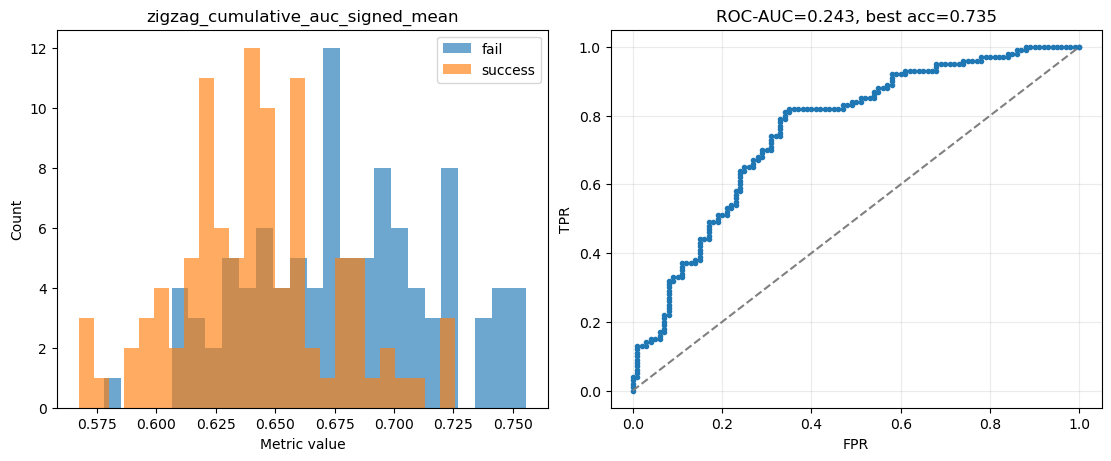

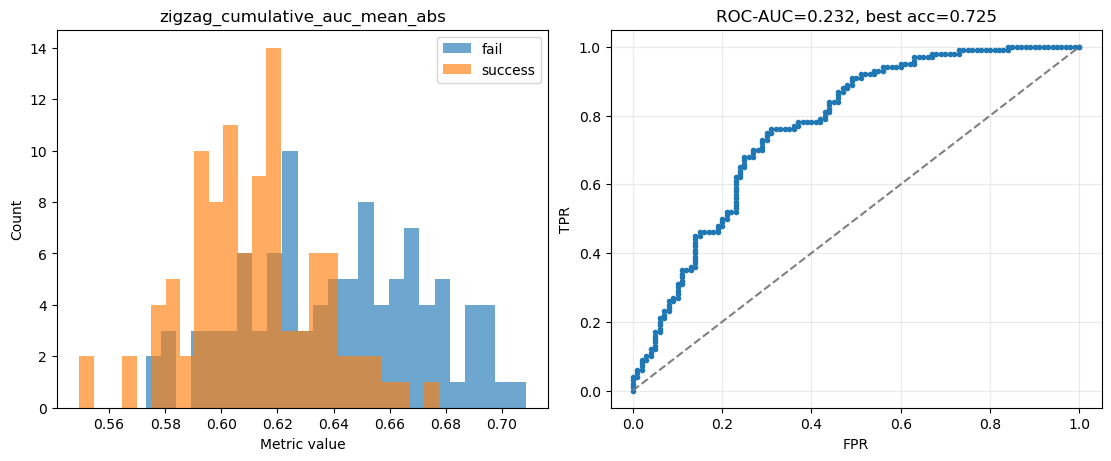

In [6]:
zigzag_metric_names = [f"zigzag_cumulative_auc_{mode}" for mode in zigzag_modes]
zigzag_quality = pd.DataFrame(metric_quality_rows(
    zigzag_metrics_df["success"].astype(bool).tolist(),
    {name: zigzag_metrics_df[name].astype("float64").to_numpy() for name in zigzag_metric_names},
)).sort_values(["best_accuracy", "roc_auc"], ascending=False)
display(zigzag_quality)

for _, row in zigzag_quality.iterrows():
    metric = row["metric"]
    fig = plot_metric_distribution_and_roc(
        zigzag_metrics_df["success"].astype(bool).to_numpy(),
        zigzag_metrics_df[metric].astype("float64").to_numpy(),
        metric_name=metric,
        auc=float(row["roc_auc"]),
        best_accuracy=float(row["best_accuracy"]),
        direction=int(row["best_direction"]),
    )
    plt.show()
